<a href="https://colab.research.google.com/github/careervrosterm/algorithm-portfolio/blob/main/API%20Earthquake%20Scraper%20and%20Heat%20Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests
import time
from bs4 import BeautifulSoup
import geopandas as gpd
import datetime

### Data Source 1
The following request collects data on earthquakes in the United States over the last year. This table is split into "high" magnitude events that are at or above a 3 on the Richter scale, and "low" magnitude events that are below 3, but still greater than 0.5. Most earthquakes in this low magnitude category are normally not damaging, last for a short durationn, and only occur in a small radius. Higher magnitudes are, of course, a larger concern for the health and structure of impacted communities.

Data credit goes to USGS.

In [2]:
now = datetime.datetime.now()
now_text = now.strftime("%Y-%m-%d")
response = requests.get(f"https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime={now_text}&minlongitude=-140&maxlongitude=-50&minlatitude=22&maxlatitude=52")


It's a little easier to flatten out the JSON tree here in order to access data for GeoPandas.

In [3]:
df_eq = pd.json_normalize(response.json(), 'features')

# converting time from milliseconds from 1970 to year
df_eq["year"] = df_eq["properties.time"] // 31536000000 + 1970

df_low_magnitude = df_eq[(df_eq["properties.mag"] < 3.0) & (df_eq["properties.mag"] >= 0.5)]
df_high_magnitude = df_eq[df_eq["properties.mag"] >= 3.0]

In [4]:
df_low_magnitude

,type,id,properties.mag,properties.place,properties.time,properties.updated,properties.tz,properties.url,properties.detail,properties.felt,...,properties.nst,properties.dmin,properties.rms,properties.gap,properties.magType,properties.type,properties.title,geometry.type,geometry.coordinates,year
0,Feature,ci41288663,0.69,"10 km SW of Anza, CA",1783443554860,1783443758326,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,17,0.040730,0.11,52,ml,earthquake,"M 0.7 - 10 km SW of Anza, CA",Point,"[-116.759666666667, 33.502, 10.8]",2026
1,Feature,nc75391441,0.97,"13 km ENE of Cloverdale, CA",1783443015500,1783443112114,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,13,0.004921,0.03,92,md,earthquake,"M 1.0 - 13 km ENE of Cloverdale, CA",Point,"[-122.879165649414, 38.8418350219727, 2.289999...",2026
2,Feature,nc75391436,0.76,"6 km NW of The Geysers, CA",1783442606060,1783442700991,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,9,0.010720,0.01,97,md,earthquake,"M 0.8 - 6 km NW of The Geysers, CA",Point,"[-122.796501159668, 38.821834564209, 2.5799999...",2026
3,Feature,tx2026ngnyyg,1.80,"24 km ESE of Balmorhea, Texas",1783442443940,1783442626557,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,5,0.200000,0.20,250,ml,earthquake,"M 1.8 - 24 km ESE of Balmorhea, Texas",Point,"[-103.513, 30.883, 0]",2026
4,Feature,ci41288647,1.79,"3 km ESE of Brea, CA",1783441823360,1783442437200,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,69,0.050860,0.25,56,ml,earthquake,"M 1.8 - 3 km ESE of Brea, CA",Point,"[-117.872, 33.903, 5.57]",2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Feature,nc75391076,1.96,"5 km NW of Johnsville, CA",1783383846250,1783396644033,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,6,0.275800,0.16,122,md,earthquake,"M 2.0 - 5 km NW of Johnsville, CA",Point,"[-120.732330322266, 39.8089981079102, 7.269999...",2026
101,Feature,tx2026nfhigo,1.80,"24 km SE of Seminole, Texas",1783383351978,1783386011859,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,10,0.100000,0.60,111,ml,earthquake,"M 1.8 - 24 km SE of Seminole, Texas",Point,"[-102.471, 32.558, 13.7475]",2026
102,Feature,tx2026nfhhja,1.90,"24 km WNW of Balmorhea, Texas",1783383314856,1783386026012,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,12,0.400000,1.00,150,ml,earthquake,"M 1.9 - 24 km WNW of Balmorhea, Texas",Point,"[-103.986, 31.052, 4.787]",2026
103,Feature,tx2026nfgzfm,1.60,"45 km NW of Toyah, Texas",1783382923677,1783429399892,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,35,0.000000,0.20,71,ml,earthquake,"M 1.6 - 45 km NW of Toyah, Texas",Point,"[-104.178, 31.56, 7.3303]",2026


In [5]:
df_high_magnitude

,type,id,properties.mag,properties.place,properties.time,properties.updated,properties.tz,properties.url,properties.detail,properties.felt,...,properties.nst,properties.dmin,properties.rms,properties.gap,properties.magType,properties.type,properties.title,geometry.type,geometry.coordinates,year


### Data Source 2
The second data source is simple; it's a recent map of the United States mainland. While state boundaries may not seem relevant for earthquake locations, they provide a visual context for location, as well as an indicator for which states are impacted the most by earthquakes.

In [6]:
# US Map Files
zipfile = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"

df_states = gpd.read_file(zipfile)
df_states

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
5,22,01629543,0400000US22,22,LA,Louisiana,00,111897594374,23753621895,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2..."
6,26,01779789,0400000US26,26,MI,Michigan,00,146600952990,103885855702,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ..."
7,25,00606926,0400000US25,25,MA,Massachusetts,00,20205125364,7129925486,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ..."
8,16,01779783,0400000US16,16,ID,Idaho,00,214049787659,2391722557,"POLYGON ((-117.24267 44.39655, -117.23484 44.3..."
9,12,00294478,0400000US12,12,FL,Florida,00,138949136250,31361101223,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ..."


## Earthquakes of Low Magnitude

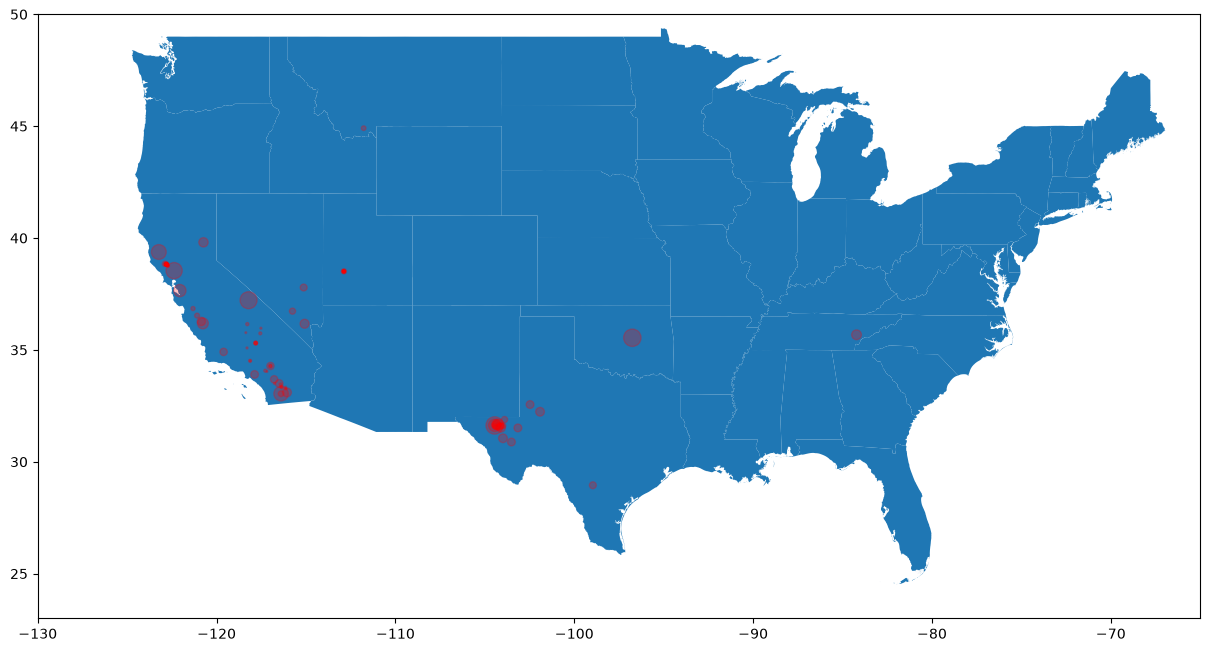

In [7]:
import geopandas as gpd

ax = df_states.to_crs("EPSG:4326").plot(figsize = (15, 15))
ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)
df_low_magnitude['size'] = 10 ** df_low_magnitude['properties.mag']

gdf_low = gpd.GeoDataFrame(
    df_low_magnitude,
    geometry=gpd.points_from_xy(
        x=df_low_magnitude["geometry.coordinates"].str[0],
        y=df_low_magnitude["geometry.coordinates"].str[1]
    ),
    crs="EPSG:4326"
)

if len(gdf_low) > 0:
    gdf_low.plot(ax=ax, color="red", alpha=0.25, markersize= df_low_magnitude['size']/2)

## Earthquakes of High Magnitude

One edge case here that occured was the dataframe being empty. Somehow I had not considered this initially! 
To fix the issue, the geodataframe will only plot its points if it has more than 0 rows (i.e.... not empty).

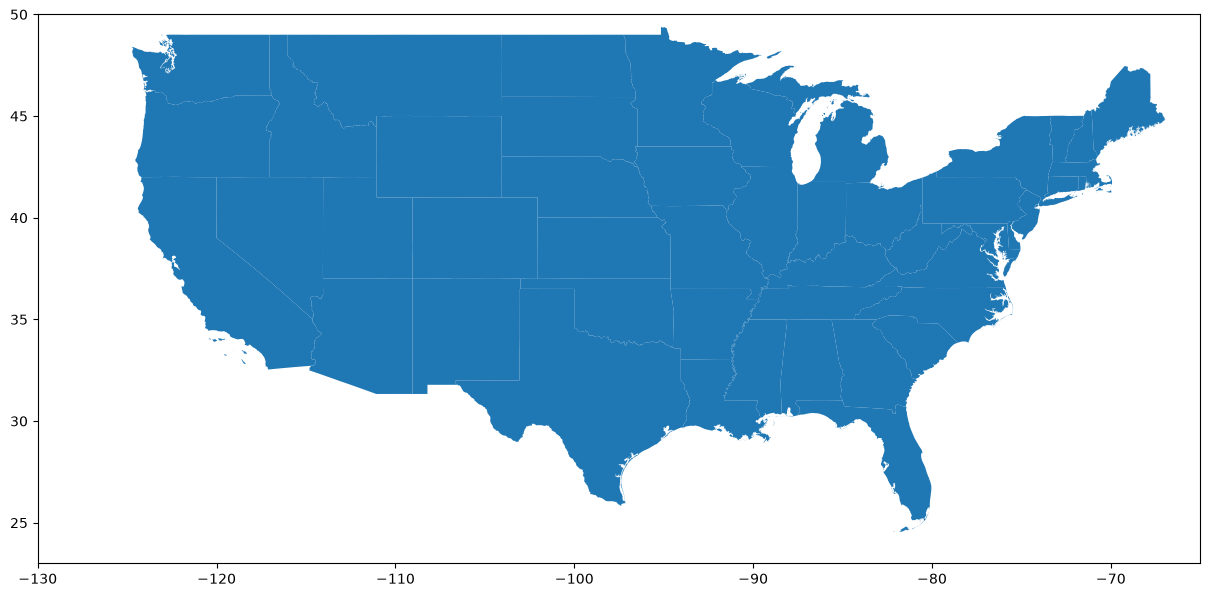

In [8]:
import geopandas as gpd

ax = df_states.to_crs("EPSG:4326").plot(figsize = (15, 15))
ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)
df_high_magnitude['size'] = 10 ** df_high_magnitude['properties.mag']

gdf_high = gpd.GeoDataFrame(
    df_high_magnitude,
    geometry=gpd.points_from_xy(
        x=df_high_magnitude["geometry.coordinates"].str[0],
        y=df_high_magnitude["geometry.coordinates"].str[1]
    ),
    crs="EPSG:4326"
)

if len(gdf_high) > 0:
    gdf_high.plot(ax=ax, color="red", alpha=0.3, markersize= df_high_magnitude['size']/20)

### A Summary of the Data
Most earthquakes, particularly of relatively higher magnitude, landed on the San Andreas fault, as well as Texas, Oklahoma, and Nevada.

Two conclusions can be made from this, both of which are fairly straightforward.
1. Active fault lines can be approximated from locations with high activity with a linear spacial pattern.
2. Some states, far more than others, need resources to deal with crises, such as government funding for disaster relief, insurance, and reinforcements in infrastructure to prevent major damage.
3. We can use this data to project the location and magnitude range for upcoming earthquakes using historical data.